#### MASINDE VICTOR
#### DATA ANALYST

### CROP YIELDS PROJECT
Food is the most basic need for all living things, including humans. With rising population, shrinking farmland, and climate change, food security needs greater attention. In this project, we will explore different crops, their yields in different soil types and climates, and the effects of fertilizer use.

In [1]:
# Import the necessary libraries to be used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 1. DATA UNDERSTANDING
Import data to the notebook and check its general properties.

In [2]:
# Import the dataset to be used for analysis and preview
df = pd.read_csv('crop_yield.csv')
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
# Check for the shape of the dataset
df.shape

(1000000, 10)

In [4]:
# check for the summary information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [5]:
# Check the statistical summary of the dataset
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


The `crop_yield` dataset has 1,000,000 rows and 10 columns with no missing values. The datatypes present in the dataset are Booleans, object, float and interger. The float and intergers are what makes up the data displayed in the statistical summary.

### 2. Data Cleaning
At this stage we want to ensure our data is ready for analysis and modelling. We check for null values and remove them if any. Duplicates are also dropped at this stage. Fixing data types also happens here and renaming of column names if need be. 

In [6]:
# check for nul values in the dataset
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [7]:
# check for duplicates in the dataset
df.duplicated().sum()

0

In [8]:
# Convert all column names to lowercase for consistency
df.columns = df.columns.str.lower()

### 3. EXPLORATORY DATA ANALYSIS (EDA) 
At this point we are sure our data is clean and ready for processing. We are going to use the data to check for patterns and trends . This will reveal the relationships that exist here and help us decide on the analysis/modelling trajectory that we will take

In [9]:
# How many references of each crop are in the dataset?
df['region'].value_counts()

region
North    250173
West     250074
South    250054
East     249699
Name: count, dtype: int64

<AxesSubplot:xlabel='region', ylabel='count'>

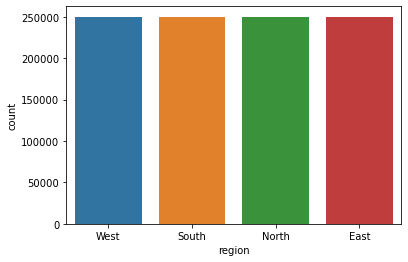

In [10]:
# Visualize the regions distribution
sns.countplot(x='region', data=df)

Region are evenly distributed in our dataset. The yields across the different regions are almost identical

In [11]:
# Create a column for months taken for the crop to be harvested
df['months_to_harvest'] = (df['days_to_harvest'] / 30).astype(int)
df.head()

,region,soil_type,crop,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used,weather_condition,days_to_harvest,yield_tons_per_hectare,months_to_harvest
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816,4
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341,4
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443,3
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573,4
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251,3


<AxesSubplot:xlabel='rainfall_mm'>

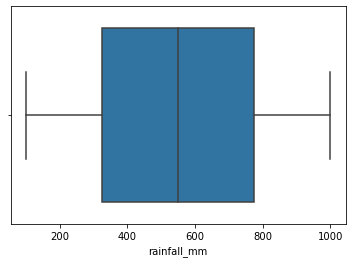

In [12]:
# Use boxplot to check the outliers in months to harvest
sns.boxplot(x=df['rainfall_mm'])  

There is no outliers in the amount of rainfall received. The rainfall levels are evenly distributed.

<AxesSubplot:>

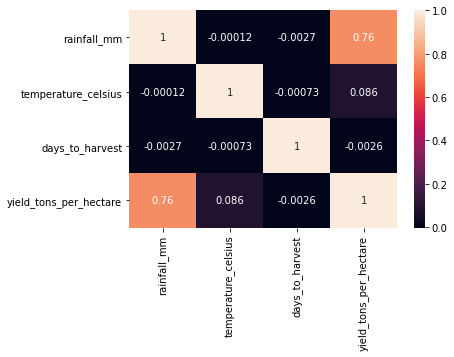

In [13]:
# Check relationships between variables
numeric_cols = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_cols.corr(), annot=True)

There is a strong positive correlation between rainfall and crop yield, suggesting that increased rainfall is associated with higher production. In contrast, days to harvest shows a negligible negative correlation (-0.0026), indicating no meaningful relationship with yield.

In [20]:
# Check the relationship between region and crop type
# Both region and crop are categorical variables, so we can use a crosstab to see the frequency of each crop type in each region
pd.crosstab(df['region'], df['crop'])

crop,Barley,Cotton,Maize,Rice,Soybean,Wheat
region,,,,,,
East,41592,41846,41530,41515,41984,41232
North,41776,41544,41830,41925,41119,41979
South,41704,41503,41725,41707,41635,41780
West,41705,41692,41739,41645,41611,41682


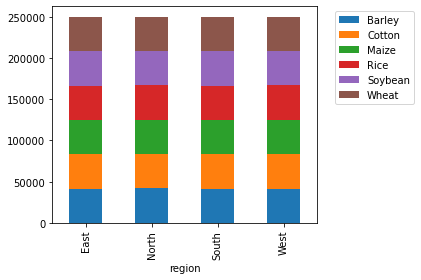

In [15]:
# Represent the relationship between region and crop type using a stacked bar chart
ct= pd.crosstab(df['region'], df['crop'])
ct.plot(kind='bar', stacked=True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<AxesSubplot:xlabel='rainfall_mm', ylabel='yield_tons_per_hectare'>

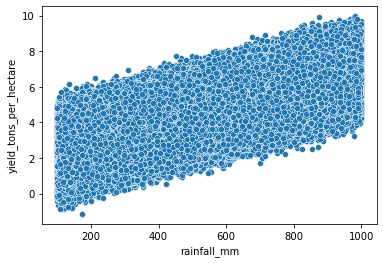

In [16]:
sns.scatterplot(x='rainfall_mm', y='yield_tons_per_hectare', data=df)

The regions in our data are uniformly distributed

There is a strong positive correlation between rainfall and crop yield, suggesting that increased rainfall is associated with higher production. From the scatter plot above we see that with increase in rainfall amounts, there is an associated increase in the amount of yields

In [22]:
#Average yield by crop
crop_yield = df.groupby('crop')['yield_tons_per_hectare'].agg(
    mean_yield='mean',
    median_yield='median',
    std_yield='std',
    count='count'
).sort_values('mean_yield', ascending=False)
crop_yield

,mean_yield,median_yield,std_yield,count
crop,,,,
Soybean,4.653712,4.657371,1.696774,166349
Wheat,4.652740,4.655529,1.694823,166673
Cotton,4.650841,4.650913,1.695367,166585
Rice,4.650760,4.652837,1.698143,166792
Barley,4.647412,4.650378,1.698294,166777
Maize,4.641387,4.642647,1.696023,166824


In [23]:
#Average yield by soil type
soil_yield = df.groupby('soil_type')['yield_tons_per_hectare'].agg(
    mean_yield='mean',
    median_yield='median',
    count='count'
).sort_values('mean_yield', ascending=False)
soil_yield

,mean_yield,median_yield,count
soil_type,,,
Chalky,4.652895,4.661322,166779
Peaty,4.651063,4.655080,166283
Loam,4.651056,4.648692,166795
Sandy,4.648511,4.648330,167119
Silt,4.648414,4.649454,166672
Clay,4.644891,4.647424,166352


In [ ]:
#Average yield by region
region_yield = df.groupby('region')['yield_tons_per_hectare'].agg(
    mean_yield='mean',
    median_yield='median',
    std_yield='std',
    count='count'
).sort_values('mean_yield', ascending=False)
region_yield

,mean_yield,median_yield,std_yield,count
region,,,,
North,4.654114,4.659441,1.696369,250173
West,4.649331,4.651359,1.695569,250074
South,4.648843,4.646668,1.697191,250054
East,4.645594,4.649821,1.697160,249699


From the above analysis using groupby to check how region, type of crop and type of soil shows a uniform distribution in yields tons per hectare. It suggests that these three factpors do not affect farming output, while in real sense it does. For this reason we will consider using the random forest model after the baseline model as it can capture hidden relationships between features and targets.